In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers

In [ ]:
import os
import re
import gc
import cv2
import h5py
import torch
import string
import random
import numpy as np
import tensorflow as tf

from tqdm import tqdm
from nltk import tokenize
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.chunk import tree2conlltags
from sklearn import preprocessing
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from keras.preprocessing.text import Tokenizer, text_to_word_sequence
#from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.layers import Rescaling, Resizing
from keras import Input
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.xception import Xception
from keras.applications import ResNet50, ResNet101, ResNet152
from keras.applications import DenseNet121, DenseNet169, DenseNet201
from keras.applications.efficientnet import EfficientNetB7
from transformers import BertTokenizer, BertForMaskedLM, BertModel
from keras import Model

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:

IMAGE_SIZE = (224, 224)
NUM_CHANNELS = 3

In [ ]:
mvsa_single_path = '/content/drive/MyDrive/mvsa-data/mvsa-single-4511.hdf5'
mvsa_multiple_path = '/content/drive/MyDrive/mvsa-data/mvsa-multiple-17024.hdf5'

In [ ]:
def clean_text(txt):
  at_pattern = re.compile('@[a-zA-Z0-9]+')
  http_pattern = re.compile("((http|ftp|https)://)(([a-zA-Z0-9\._-]+\.[a-zA-Z]{2,6})|([0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}))(:[0-9]{1,4})*(/[a-zA-Z0-9\&%_\./-~-]*)?")
  punc_pattern = re.compile('[%s]' % re.escape(string.punctuation))
  #txt = re.sub('#', '', txt)
  txt = re.sub(at_pattern, 'user', txt)
  txt = re.sub(http_pattern, 'link', txt)
  # as the data was crawled using Twitter API, it marked retweet data with RT <user> tag which has no meaning considering it in training
  if txt.startswith('RT user'):
    txt = ''.join(txt.split(':')[1:])
    #txt = re.sub(punc_pattern, '', txt) # ONLY REMOVE punc for word2vec not BERT
    txt = txt.strip().lower()
  return txt
def get_clean_texts(data):
  cleaned_data = []
  for line in data:
    text = clean_text(line)
    cleaned_data.append(text)
  return cleaned_data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def get_bow(vectorizer, data):
    bow = vectorizer.transform(data).toarray()
    scaler = MinMaxScaler()
    bow_scaled = scaler.fit_transform(bow)
    return bow_scaled

def get_tfidf(vectorizer, data):
    tfidf = vectorizer.transform(data).toarray()
    return tfidf

In [ ]:
def get_pos(text):
  tokens_tag = np.array(pos_tag(word_tokenize(text)))
  #print(tokens_tag)
  return tokens_tag[:, 1]

def create_pos_data(data):
  pos_data = []
  for line in tqdm(data):
    try:
      pos = ' '.join(get_pos(line))
    except:
      pos = ''
    pos_data.append(pos)
  return pos_data

In [ ]:
def get_ner(text):
  tokens_ne = np.array(tree2conlltags(ne_chunk(pos_tag(word_tokenize(text)))))
  #print(tokens_ne)
  return tokens_ne[:, 2]

def create_ner_data(data):
  ner_data = []
  for line in tqdm(data):
    try:
      ner = ' '.join(get_ner(line))
    except:
      ner = ''
    ner_data.append(ner)
  return ner_data

In [ ]:
tokens_ne = np.array(tree2conlltags(ne_chunk(pos_tag(word_tokenize('mvsa_single_texts')))))
tokens_ne

# def create_ner_data(data):
#   ner_data = []
#   for line in tqdm(data):
#     try:
#       ner = ' '.join(get_ner(line))
#     except:
#       ner = ''
#     ner_data.append(ner)
#   return ner_data

array([['mvsa_single_texts', 'NN', 'O']], dtype='<U17')

In [ ]:
def read_hdf5(path):
    read_file = h5py.File(path, 'r')

    feature_names = list(read_file.keys())
    loaded_data = []

    for name in feature_names:
        dataset = read_file[name][:]
        if dataset.dtype == np.dtype('object'):
            dataset = np.array([x.decode('UTF-8') for x in dataset])
        loaded_data.append((name, dataset))

    return loaded_data

In [ ]:



def load_mvsa_data(path):
    data = read_hdf5(path)
    for x in data:
        if x[0] == 'texts':
            texts = x[1]
        if x[0] == 'multimodal-labels':
            labels = x[1]
        if x[0] == 'text-labels':
            text_labels = x[1]
        if x[0] == 'image-labels':
            image_labels = x[1]

    images_path = os.path.join(os.path.split(path)[0], os.path.split(path)[1].split('.')[0] + '-images.npz')
    images = loadz(images_path)

    return texts, images, labels, text_labels, image_labels

def loadz(path):
    data = np.load(path)['arr_0']
    return data

# Load raw data

In [ ]:

mvsa_single_texts, mvsa_single_images, \
mvsa_single_multimodal_labels, mvsa_single_text_labels, \
mvsa_single_image_labels = load_mvsa_data(mvsa_single_path)
num_mvsa_single = len(mvsa_single_texts)

mvsa_multiple_texts, mvsa_multiple_images, \
mvsa_multiple_multimodal_labels, mvsa_multiple_text_labels, \
mvsa_multiple_image_labels = load_mvsa_data(mvsa_multiple_path)
num_mvsa_multiple = len(mvsa_multiple_texts)

-----Sample-----
Text label: neutral
Image label: neutral
Multimodal label: neutral
Text: $129.¡­ http://t.co/Olj5nUQTaP
Image:


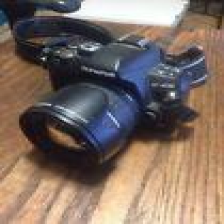

In [ ]:
SAMPLE = random.choice(range(num_mvsa_single))
print('-----Sample-----')
print('Text label:', mvsa_single_text_labels[SAMPLE])
print('Image label:', mvsa_single_image_labels[SAMPLE])
print('Multimodal label:', mvsa_single_multimodal_labels[SAMPLE])
print('Text:', mvsa_single_texts[SAMPLE])
print('Image:')
tf.keras.utils.array_to_img(mvsa_single_images[SAMPLE])

-----Sample-----
Text label: neutral
Image label: neutral
Multimodal label: neutral
Text: #BlueJays game with @shanegall23 ??????
Image:


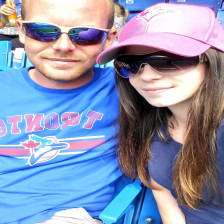

In [ ]:
SAMPLE = random.choice(range(num_mvsa_multiple))
print('-----Sample-----')
print('Text label:', mvsa_multiple_text_labels[SAMPLE])
print('Image label:', mvsa_multiple_image_labels[SAMPLE])
print('Multimodal label:', mvsa_multiple_multimodal_labels[SAMPLE])
print('Text:', mvsa_multiple_texts[SAMPLE])
print('Image:')
tf.keras.utils.array_to_img(mvsa_multiple_images[SAMPLE])

# Preprocess text

In [ ]:
mvsa_single_texts = get_clean_texts(mvsa_single_texts)
mvsa_multiple_texts = get_clean_texts(mvsa_multiple_texts)

In [ ]:
#mvsa_single_texts

# Labels to file

In [ ]:
with h5py.File('mvsa-single-labels.hdf5', 'w') as f:
    f.create_dataset('multimodal-labels', data = mvsa_single_multimodal_labels.astype('object'))
    f.create_dataset('text-labels', data = mvsa_single_text_labels.astype('object'))
    f.create_dataset('image-labels', data = mvsa_single_image_labels.astype('object'))

In [ ]:
with h5py.File('mvsa-multiple-labels.hdf5', 'w') as f:
    f.create_dataset('multimodal-labels', data = mvsa_multiple_multimodal_labels.astype('object'))
    f.create_dataset('text-labels', data = mvsa_multiple_text_labels.astype('object'))
    f.create_dataset('image-labels', data = mvsa_multiple_image_labels.astype('object'))

# POS

In [ ]:
mvsa_single_texts[1]

'grattis min griskulting!!!???? va bara tvungen oki s? sch ? user #pig #happybday #wow #lovely #cut¡\xad '

In [ ]:
mvsa_single_pos = create_pos_data(mvsa_single_texts)
mvsa_multiple_pos = create_pos_data(mvsa_multiple_texts)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
mvsa_single_pos

In [ ]:
count_vectorizer = CountVectorizer()
count_vectorizer.fit(mvsa_single_pos + mvsa_multiple_pos)

tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(mvsa_single_pos + mvsa_multiple_pos)

In [ ]:
mvsa_single_pos_bow = get_bow(count_vectorizer, mvsa_single_pos)
mvsa_multiple_pos_bow = get_bow(count_vectorizer, mvsa_multiple_pos)

mvsa_single_pos_tfidf = get_tfidf(tfidf_vectorizer, mvsa_single_pos)
mvsa_multiple_pos_tfidf = get_tfidf(tfidf_vectorizer, mvsa_multiple_pos)

In [ ]:
mvsa_multiple_pos_bow[89], mvsa_single_pos_tfidf[89]

In [ ]:
# save and load check
np.savez('./mvsa-single-pos-bow', mvsa_single_pos_bow)
x = loadz('./mvsa-single-pos-bow.npz')
print((x == mvsa_single_pos_bow).all())

# save and load check
np.savez('./mvsa-multiple-pos-bow', mvsa_multiple_pos_bow)
x = loadz('./mvsa-multiple-pos-bow.npz')
print((x == mvsa_multiple_pos_bow).all())

# save and load check
np.savez('./mvsa-single-pos-tfidf', mvsa_single_pos_tfidf)
x = loadz('./mvsa-single-pos-tfidf.npz')
print((x == mvsa_single_pos_tfidf).all())

# save and load check
np.savez('./mvsa-multiple-pos-tfidf', mvsa_multiple_pos_tfidf)
x = loadz('./mvsa-multiple-pos-tfidf.npz')
print((x == mvsa_multiple_pos_tfidf).all())

# NER

In [ ]:
#mvsa_single_texts

In [ ]:
mvsa_single_ner = create_ner_data(mvsa_single_texts)
mvsa_multiple_ner = create_ner_data(mvsa_multiple_texts)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
mvsa_single_ner

In [ ]:
count_vectorizer2 = CountVectorizer()
count_vectorizer2.fit(mvsa_single_ner + mvsa_multiple_ner)

tfidf_vectorizer2 = TfidfVectorizer()
tfidf_vectorizer2.fit(mvsa_single_ner + mvsa_multiple_ner)

In [ ]:
mvsa_single_ner_bow = get_bow(count_vectorizer2, mvsa_single_ner)
mvsa_multiple_ner_bow = get_bow(count_vectorizer2, mvsa_multiple_ner)

mvsa_single_ner_tfidf = get_tfidf(tfidf_vectorizer2, mvsa_single_ner)
mvsa_multiple_ner_tfidf = get_tfidf(tfidf_vectorizer2, mvsa_multiple_ner)

In [ ]:
# save and load check
np.savez('./mvsa-single-ner-bow', mvsa_single_ner_bow)
x = loadz('./mvsa-single-ner-bow.npz')
print((x == mvsa_single_ner_bow).all())

# save and load check
np.savez('./mvsa-multiple-ner-bow', mvsa_multiple_ner_bow)
x = loadz('./mvsa-multiple-ner-bow.npz')
print((x == mvsa_multiple_ner_bow).all())

# save and load check
np.savez('./mvsa-single-ner-tfidf', mvsa_single_ner_tfidf)
x = loadz('./mvsa-single-ner-tfidf.npz')
print((x == mvsa_single_ner_tfidf).all())

# save and load check
np.savez('./mvsa-multiple-ner-tfidf', mvsa_multiple_ner_tfidf)
x = loadz('./mvsa-multiple-ner-tfidf.npz')
print((x == mvsa_multiple_ner_tfidf).all())


### **SBERT-base**

In [ ]:
!pip install -U sentence-transformers

In [ ]:
mvsa_total=np.concatenate((mvsa_single_texts, mvsa_multiple_texts))

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

.gitattributes:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

train_script.py:   0%|          | 0.00/13.2k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

In [ ]:
# sentences = mvsa_total
# sentence_embeddings = model.encode(sentences)

In [ ]:
# for sentence, embedding in zip(sentences, sentence_embeddings):
#     print("Sentence:", sentence)
#     print("Embedding:", embedding)
#     print("")

In [ ]:
print('MVSA-Single: Extracting bert features of texts')
mvsa_single_sbert_base =model.encode(mvsa_single_texts)


# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/mvsa-single-sbert-base', mvsa_single_sbert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/mvsa-single-sbert-base.npz')
print((x == mvsa_single_sbert_base).all())

MVSA-Single: Extracting bert features of texts
True


In [ ]:
print('MVSA-Single: Extracting bert features of texts')
mvsa_multiple_sbert_base =model.encode(mvsa_multiple_texts)


# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/mvsa-multiple-sbert-base', mvsa_multiple_sbert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/mvsa-multiple-sbert-base.npz')
print((x == mvsa_multiple_sbert_base).all())

MVSA-Single: Extracting bert features of texts
True


In [ ]:
print('MVSA-Single: Extracting bert features of texts')
mvsa_sbert_base =model.encode(mvsa_total)


# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/mvsa-sbert-base', mvsa_sbert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/mvsa-sbert-base.npz')
print((x == mvsa_sbert_base).all())

MVSA-Single: Extracting bert features of texts


NameError: ignored

# BERT-base

In [ ]:
MAX_LENGTH = 280 # as in twitter word limit

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')# bert_model = BertForMaskedLM.from_pretrained('bert-base-uncased', return_dict = True)
bert_model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True)
# bert_model.eval() # (evaluation mode is default) put model in evaluation model, turn of regularization in training

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
def bert_embed_sentence(text, tokenizer=bert_tokenizer, model=bert_model):
#     inputs = tokenizer(text, return_tensors='pt', max_length=MAX_LENGTH, padding='max_length')
    inputs = tokenizer(text, return_tensors='pt')

    with torch.no_grad():
        outputs = model(**inputs, )
        last_hidden_states = outputs.hidden_states[-1][0]
        cls_token = last_hidden_states[0]
        bert_embeddings = torch.squeeze(cls_token, dim=0).numpy()

    return bert_embeddings

In [ ]:
def bert_embed_data(data):
    embedded_data = np.array([])

    for line in tqdm(data):
        bert_embeddings = bert_embed_sentence(line)
        if embedded_data.shape[0] == 0:
            embedded_data = np.array([bert_embeddings])#np.empty((0, embedded_line.shape[0]), 'float32')
        else:
            embedded_data = np.concatenate((embedded_data, [bert_embeddings]))

    return embedded_data

In [ ]:
print('MVSA-Single: Extracting bert features of texts')
mvsa_single_bert_base = bert_embed_data(mvsa_single_texts)
print('BERT-base CLS token in last hidden layer dimension:', mvsa_single_bert_base.shape[1])
print('MVSA-Single with BERT-base CLS token in last hidden layer:', mvsa_single_bert_base.shape)

# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-single-bert-base-woutp', mvsa_single_bert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-single-bert-base-woutp.npz')
print((x == mvsa_single_bert_base).all())

MVSA-Single: Extracting bert features of texts


100%|██████████| 4511/4511 [14:45<00:00,  5.09it/s]


BERT-base CLS token in last hidden layer dimension: 768
MVSA-Single with BERT-base CLS token in last hidden layer: (4511, 768)
True


In [ ]:
# prompt: Read npz mvsa_single_bert_base

mvsa_single_bert_base = loadz('/content/drive/MyDrive/MVSA_features/bert/mvsa-single-bert.npz')


In [ ]:
# prompt: Input mvsa_single_bert_base to a LSTM of output 100 and droput 0.5. And save all the outputs in one npz

from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.losses import MeanSquaredError
from keras.optimizers import Adam
from keras.metrics import MeanAbsoluteError
model = Sequential([
    LSTM(100, dropout=0.5, return_sequences=True),
    #LSTM(100, dropout=0.5, return_sequences=False),
    Dense(100, activation='relu')
    #Dropout(0.5),
    #Dense(1)
])
model.compile(loss=MeanSquaredError(), optimizer=Adam(), metrics=[MeanAbsoluteError()])
model.fit(mvsa_single_bert_base, mvsa_single_bert_base, epochs=50)
model.save('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-single-bert-base-lstm-100-dropout-0.5.h5')


In [ ]:
print('MVSA-Multiple: Extracting bert features of texts')
mvsa_multiple_bert_base = bert_embed_data(mvsa_multiple_texts)
print('BERT-base CLS token in last hidden layer dimenion:', mvsa_multiple_bert_base.shape[1])
print('MVSA-Multiple with BERT-base CLS token in last hidden layer:', mvsa_multiple_bert_base.shape)

# save and load check--
np.savez('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-multiple-bert-base-woutp', mvsa_multiple_bert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-multiple-bert-base-woutp.npz')
print((x == mvsa_multiple_bert_base).all())

MVSA-Multiple: Extracting bert features of texts


100%|██████████| 17024/17024 [57:27<00:00,  4.94it/s]


BERT-base CLS token in last hidden layer dimenion: 768
MVSA-Multiple with BERT-base CLS token in last hidden layer: (17024, 768)
True


In [ ]:
type(mvsa_multiple_texts+mvsa_single_texts )

In [ ]:
len(mvsa_multiple_texts)

In [ ]:
print('MVSA-Multiple: Extracting bert features of texts')
mvsa_bert_base = bert_embed_data(mvsa_multiple_texts+mvsa_single_texts)
print('BERT-base CLS token in last hidden layer dimenion:', mvsa_bert_base.shape[1])
print('MVSA-Multiple with BERT-base CLS token in last hidden layer:', mvsa_bert_base.shape)

# save and load check08
np.savez('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-bert-base-woutp', mvsa_bert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-bert-base-woutp.npz')
print((x == mvsa_bert_base).all())

MVSA-Multiple: Extracting bert features of texts


100%|██████████| 21535/21535 [57:40<00:00,  6.22it/s]


BERT-base CLS token in last hidden layer dimenion: 768
MVSA-Multiple with BERT-base CLS token in last hidden layer: (21535, 768)
True


# roberta-base

In [ ]:
MAX_LENGTH = 280 # as in twitter word limit

In [ ]:
from transformers import RobertaTokenizer, TFRobertaModel
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = TFRobertaModel.from_pretrained('roberta-base')
# text = "Replace me by any text you'd like."
# encoded_input = tokenizer(text, return_tensors='tf')
# output = model(encoded_input)



vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def rbert_embed_sentence(text, tokenizer=bert_tokenizer, model=bert_model):
#     inputs = tokenizer(text, return_tensors='pt', max_length=MAX_LENGTH, padding='max_length')
    inputs = tokenizer(text, return_tensors='pt')

    with torch.no_grad():
        outputs = model(inputs)
        last_hidden_states = outputs.hidden_states[-1][0]
        cls_token = last_hidden_states[0]
        bert_embeddings = torch.squeeze(cls_token, dim=0).numpy()

    return bert_embeddings

In [ ]:
def rbert_embed_data(data):
    embedded_data = np.array([])

    for line in tqdm(data):
        bert_embeddings = rbert_embed_sentence(line)
        if embedded_data.shape[0] == 0:
            embedded_data = np.array([bert_embeddings])#np.empty((0, embedded_line.shape[0]), 'float32')
        else:
            embedded_data = np.concatenate((embedded_data, [bert_embeddings]))

    return embedded_data

In [ ]:
print('MVSA-Single: Extracting bert features of texts')
mvsa_single_rbert_base = rbert_embed_data(mvsa_single_texts)
print('BERT-base CLS token in last hidden layer dimension:', mvsa_single_rbert_base.shape[1])
print('MVSA-Single with BERT-base CLS token in last hidden layer:', mvsa_single_rbert_base.shape)

# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/rbert-base/mvsa-single-rbert-base-woutp', mvsa_single_bert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/rbert-base/mvsa-single-rbert-base-woutp.npz')
print((x == mvsa_single_bert_base).all())

MVSA-Single: Extracting bert features of texts


100%|██████████| 4511/4511 [14:45<00:00,  5.09it/s]


BERT-base CLS token in last hidden layer dimension: 768
MVSA-Single with BERT-base CLS token in last hidden layer: (4511, 768)
True


In [ ]:
print('MVSA-Multiple: Extracting bert features of texts')
mvsa_multiple_rbert_base = rbert_embed_data(mvsa_multiple_texts)
print('BERT-base CLS token in last hidden layer dimenion:', mvsa_multiple_rbert_base.shape[1])
print('MVSA-Multiple with BERT-base CLS token in last hidden layer:', mvsa_multiple_rbert_base.shape)

# save and load check--
np.savez('/content/drive/MyDrive/MVSA_features/rbert-base/mvsa-multiple-rbert-base-woutp', mvsa_multiple_rbert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/rbert-base/mvsa-multiple-rbert-base-woutp.npz')
print((x == mvsa_multiple_rbert_base).all())

MVSA-Multiple: Extracting bert features of texts


 67%|██████▋   | 11453/17024 [36:36<16:35,  5.59it/s]

In [ ]:
type(mvsa_multiple_texts+mvsa_single_texts )

In [ ]:
len(mvsa_multiple_texts)

In [ ]:
print('MVSA-Multiple: Extracting bert features of texts')
mvsa_bert_base = bert_embed_data(mvsa_multiple_texts+mvsa_single_texts)
print('BERT-base CLS token in last hidden layer dimenion:', mvsa_bert_base.shape[1])
print('MVSA-Multiple with BERT-base CLS token in last hidden layer:', mvsa_bert_base.shape)

# save and load check08
np.savez('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-bert-base-woutp', mvsa_bert_base)
x = loadz('/content/drive/MyDrive/MVSA_features/bert-base/mvsa-bert-base-woutp.npz')
print((x == mvsa_bert_base).all())

MVSA-Multiple: Extracting bert features of texts


100%|██████████| 21535/21535 [57:40<00:00,  6.22it/s]


BERT-base CLS token in last hidden layer dimenion: 768
MVSA-Multiple with BERT-base CLS token in last hidden layer: (21535, 768)
True


# VGG-16

In [ ]:
vgg16 = VGG16(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
vgg16.trainable = False # Freeze pre-trained layers
vgg16_last = Model(inputs=vgg16.input, outputs=vgg16.layers[-2].output) # output of last hidden layer

553467096/553467096 [==============================] - 20s 0us/step


In [ ]:
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = vgg16_last (rescale_layer)
model_vgg16 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting VGG-16 features of images')
mvsa_single_vgg16 = model_vgg16.predict(mvsa_single_images, verbose=1)
print('VGG-16 last hidden layer dimension:', mvsa_single_vgg16.shape[1])
print('MVSA-Single with VGG-16 last hidden layer:', mvsa_single_vgg16.shape)

# save and load check
np.savez('./mvsa-single-vgg16', mvsa_single_vgg16)
x = loadz('./mvsa-single-vgg16.npz')
print((x == mvsa_single_vgg16).all())

MVSA-Single: Extracting VGG-16 features of images
141/141 [==============================] - 3285s 23s/step
VGG-16 last hidden layer dimension: 4096
MVSA-Single with VGG-16 last hidden layer: (4511, 4096)
True


In [ ]:
print('MVSA-Multiple: Extracting VGG-16 features of images')
mvsa_multiple_vgg16 = model_vgg16.predict(mvsa_multiple_images, verbose=1)
print('VGG-16 last hidden layer dimension:', mvsa_multiple_vgg16.shape[1])
print('MVSA-Multiple with VGG-16 last hidden layer:', mvsa_multiple_vgg16.shape)

# save and load check
np.savez('./mvsa-multiple-vgg16', mvsa_multiple_vgg16)
x = loadz('./mvsa-multiple-vgg16.npz')
print((x == mvsa_multiple_vgg16).all())

MVSA-Multiple: Extracting VGG-16 features of images
532/532 [==============================] - 10043s 19s/step
VGG-16 last hidden layer dimension: 4096
MVSA-Multiple with VGG-16 last hidden layer: (17024, 4096)
True


# VGG-19

In [ ]:
vgg19 = VGG19(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
vgg19.trainable = False # Freeze pre-trained layers
vgg19_last = Model(inputs=vgg19.input, outputs=vgg19.layers[-2].output) # output of last hidden layer

# Summary of VGG-19 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = vgg19_last (rescale_layer)
model_vgg19 = Model(inputs=image_inputs, outputs=outputs)

574710816/574710816 [==============================] - 8s 0us/step


In [ ]:
# Summary of VGG-19 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = vgg19_last (rescale_layer)
model_vgg19 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting VGG-19 features of images')
mvsa_single_vgg19 = model_vgg19.predict(mvsa_single_images, verbose=1)
print('VGG-19 last hidden layer dimension:', mvsa_single_vgg19.shape[1])
print('MVSA-Single with VGG-19 last hidden layer:', mvsa_single_vgg19.shape)

# save and load check
np.savez('./mvsa-single-vgg19', mvsa_single_vgg19)
x = loadz('./mvsa-single-vgg19.npz')
print((x == mvsa_single_vgg19).all())

MVSA-Single: Extracting VGG-19 features of images
 78/141 [===============>..............] - ETA: 23:57

In [ ]:
print('MVSA-Multiple: Extracting VGG-19 features of images')
mvsa_multiple_vgg19 = model_vgg19.predict(mvsa_multiple_images, verbose=1)
print('VGG-19 last hidden layer dimension:', mvsa_multiple_vgg19.shape[1])
print('MVSA-Multiple with VGG-19 last hidden layer:', mvsa_multiple_vgg19.shape)

# save and load check
np.savez('./mvsa-multiple-vgg19', mvsa_multiple_vgg19)
x = loadz('./mvsa-multiple-vgg19.npz')
print((x == mvsa_multiple_vgg19).all())

# Xception

In [ ]:
IMAGE_SIZE_XCEPTION = (299, 299)

In [ ]:
xception = Xception(input_shape=(IMAGE_SIZE_XCEPTION[0], IMAGE_SIZE_XCEPTION[1], NUM_CHANNELS))
xception.trainable = False # Freeze pre-trained layers
xception_last = Model(inputs=xception.input, outputs=xception.layers[-2].output) # output of last hidden layer

In [ ]:
# Summary of VGG-19 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
resize_layer = Resizing(IMAGE_SIZE_XCEPTION[0], IMAGE_SIZE_XCEPTION[1]) (image_inputs)
rescale_layer = Rescaling(scale=1./255.) (resize_layer)  # Rescale inputs
outputs = xception_last (rescale_layer)
model_xception = Model(inputs=image_inputs, outputs=outputs)
model_xception.summary()

In [ ]:
print('MVSA-Single: Extracting Xception features of images')
mvsa_single_xception = model_xception.predict(mvsa_single_images, verbose=1)
print('Xception last hidden layer dimension:', mvsa_single_xception.shape[1])
print('MVSA-Single with Xception last hidden layer:', mvsa_single_xception.shape)

# save and load check
np.savez('./mvsa-single-xception', mvsa_single_xception)
x = loadz('./mvsa-single-xception.npz')
print((x == mvsa_single_xception).all())

In [ ]:
print('MVSA-Multiple: Extracting Xception features of images')
mvsa_multiple_xception = model_xception.predict(mvsa_multiple_images, verbose=1)
print('Xception last hidden layer dimension:', mvsa_multiple_xception.shape[1])
print('MVSA-Multiple with Xception last hidden layer:', mvsa_multiple_xception.shape)

# save and load check
np.savez('./mvsa-multiple-xception', mvsa_multiple_xception)
x = loadz('./mvsa-multiple-xception.npz')
print((x == mvsa_multiple_xception).all())

# ResNet50

In [ ]:
resnet50 = ResNet50(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
resnet50.trainable = False # Freeze pre-trained layers
resnet50_last = Model(inputs=resnet50.input, outputs=resnet50.layers[-2].output)

In [ ]:
# Summary of VGG-19 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = resnet50_last (rescale_layer)
model_resnet50 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting ResNet50 features of images')
mvsa_single_resnet50 = model_resnet50.predict(mvsa_single_images, verbose=1)
print('ResNet50 last hidden layer dimension:', mvsa_single_resnet50.shape[1])
print('MVSA-Single with ResNet50 last hidden layer:', mvsa_single_resnet50.shape)

# save and load check
np.savez('./mvsa-single-resnet50', mvsa_single_resnet50)
x = loadz('./mvsa-single-resnet50.npz')
print((x == mvsa_single_resnet50).all())

In [ ]:
print('MVSA-Multiple: Extracting ResNet50 features of images')
mvsa_multiple_resnet50 = model_resnet50.predict(mvsa_multiple_images, verbose=1)
print('ResNet50 last hidden layer dimension:', mvsa_multiple_resnet50.shape[1])
print('MVSA-Multiple with ResNet50 last hidden layer:', mvsa_multiple_resnet50.shape)

# save and load check
np.savez('./mvsa-multiple-resnet50', mvsa_multiple_resnet50)
x = loadz('./mvsa-multiple-resnet50.npz')
print((x == mvsa_multiple_resnet50).all())

# ResNet101

In [ ]:
resnet101 = ResNet101(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
resnet101.trainable = False # Freeze pre-trained layers
resnet101_last = Model(inputs=resnet101.input, outputs=resnet101.layers[-2].output)

In [ ]:
# Summary of VGG-19 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = resnet101_last (rescale_layer)
model_resnet101 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting ResNet101 features of images')
mvsa_single_resnet101 = model_resnet101.predict(mvsa_single_images, verbose=1)
print('ResNet101 last hidden layer dimension:', mvsa_single_resnet101.shape[1])
print('MVSA-Single with ResNet101 last hidden layer:', mvsa_single_resnet101.shape)

# save and load check
np.savez('./mvsa-single-resnet101', mvsa_single_resnet101)
x = loadz('./mvsa-single-resnet101.npz')
print((x == mvsa_single_resnet101).all())

In [ ]:
print('MVSA-Multiple: Extracting ResNet101 features of images')
mvsa_multiple_resnet101 = model_resnet101.predict(mvsa_multiple_images, verbose=1)
print('ResNet101 last hidden layer dimension:', mvsa_multiple_resnet101.shape[1])
print('MVSA-Multiple with ResNet101 last hidden layer:', mvsa_multiple_resnet101.shape)

# save and load check
np.savez('./mvsa-multiple-resnet101', mvsa_multiple_resnet101)
x = loadz('./mvsa-multiple-resnet101.npz')
print((x == mvsa_multiple_resnet101).all())

# ResNet152

In [ ]:
resnet152 = ResNet152(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
resnet152.trainable = False # Freeze pre-trained layers
resnet152_last = Model(inputs=resnet152.input, outputs=resnet152.layers[-2].output)

In [ ]:
# Summary of ResNet52 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = resnet152_last (rescale_layer)
model_resnet152 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting ResNet152 features of images')
mvsa_single_resnet152 = model_resnet152.predict(mvsa_single_images, verbose=1)
print('ResNet152 last hidden layer dimension:', mvsa_single_resnet152.shape[1])
print('MVSA-Single with ResNet152 last hidden layer:', mvsa_single_resnet152.shape)

# save and load check
np.savez('./mvsa-single-resnet152', mvsa_single_resnet152)
x = loadz('./mvsa-single-resnet152.npz')
print((x == mvsa_single_resnet152).all())

In [ ]:
print('MVSA-Multiple: Extracting ResNet152 features of images')
mvsa_multiple_resnet152 = model_resnet152.predict(mvsa_multiple_images, verbose=1)
print('ResNet152 last hidden layer dimension:', mvsa_multiple_resnet152.shape[1])
print('MVSA-Multiple with ResNet152 last hidden layer:', mvsa_multiple_resnet152.shape)

# save and load check
np.savez('./mvsa-multiple-resnet152', mvsa_multiple_resnet152)
x = loadz('./mvsa-multiple-resnet152.npz')
print((x == mvsa_multiple_resnet152).all())

# DenseNet121

In [ ]:
densenet121 = DenseNet121(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
densenet121.trainable = False # Freeze pre-trained layers
densenet121_last = Model(inputs=densenet121.input, outputs=densenet121.layers[-2].output)

In [ ]:
# Summary of DenseNet121 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = densenet121_last (rescale_layer)
model_densenet121 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting DenseNet121 features of images')
mvsa_single_densenet121 = model_densenet121.predict(mvsa_single_images, verbose=1)
print('DenseNet121 last hidden layer dimension:', mvsa_single_densenet121.shape[1])
print('MVSA-Single with DenseNet121 last hidden layer:', mvsa_single_densenet121.shape)

# save and load check
np.savez('./mvsa-single-densenet121', mvsa_single_densenet121)
x = loadz('./mvsa-single-densenet121.npz')
print((x == mvsa_single_densenet121).all())

In [ ]:
print('MVSA-Multiple: Extracting DenseNet121 features of images')
mvsa_multiple_densenet121 = model_densenet121.predict(mvsa_multiple_images, verbose=1)
print('DenseNet121 last hidden layer dimension:', mvsa_multiple_densenet121.shape[1])
print('MVSA-Multiple with DenseNet121 last hidden layer:', mvsa_multiple_densenet121.shape)

# save and load check
np.savez('./mvsa-multiple-densenet121', mvsa_multiple_densenet121)
x = loadz('./mvsa-multiple-densenet121.npz')
print((x == mvsa_multipledensenet121).all())

# DenseNet169

In [ ]:
densenet169 = DenseNet169(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
densenet169.trainable = False # Freeze pre-trained layers
densenet169_last = Model(inputs=densenet169.input, outputs=densenet169.layers[-2].output)

In [ ]:
# Summary of DenseNet121 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = densenet169_last (rescale_layer)
model_densenet169 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting DenseNet169 features of images')
mvsa_single_densenet169 = model_densenet169.predict(mvsa_single_images, verbose=1)
print('DenseNet169 last hidden layer dimension:', mvsa_single_densenet169.shape[1])
print('MVSA-Single with DenseNet169 last hidden layer:', mvsa_single_densenet169.shape)

# save and load check
np.savez('./mvsa-single-densenet169', mvsa_single_densenet169)
x = loadz('./mvsa-single-densenet169.npz')
print((x == mvsa_single_densenet169).all())

In [ ]:
print('MVSA-Multiple: Extracting DenseNet169 features of images')
mvsa_multiple_densenet169 = model_densenet169.predict(mvsa_multiple_images, verbose=1)
print('DenseNet169 last hidden layer dimension:', mvsa_multiple_densenet169.shape[1])
print('MVSA-Multiple with DenseNet169 last hidden layer:', mvsa_multiple_densenet169.shape)

# save and load check
np.savez('./mvsa-multiple-densenet169', mvsa_multiple_densenet169)
x = loadz('./mvsa-multiple-densenet169.npz')
print((x == mvsa_multiple_densenet169).all())

# DenseNet201

In [ ]:
densenet201 = DenseNet201(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
densenet201.trainable = False # Freeze pre-trained layers
densenet201_last = Model(inputs=densenet201.input, outputs=densenet201.layers[-2].output)

82524592/82524592 [==============================] - 0s 0us/step


In [ ]:
# Summary of DenseNet201 is hidden
image_inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
rescale_layer = Rescaling(scale=1./255.) (image_inputs)  # Rescale inputs
outputs = densenet201_last (rescale_layer)
model_densenet201 = Model(inputs=image_inputs, outputs=outputs)

In [ ]:
print('MVSA-Single: Extracting DenseNet201 features of images')
mvsa_single_densenet201 = model_densenet201.predict(mvsa_single_images, verbose=1)
print('DenseNet201 last hidden layer dimension:', mvsa_single_densenet201.shape[1])
print('MVSA-Single with DenseNet201 last hidden layer:', mvsa_single_densenet201.shape)

# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/mvsa-single-densenet201', mvsa_single_densenet201)
x = loadz('/content/drive/MyDrive/MVSA_features/mvsa-single-densenet201.npz')
print((x == mvsa_single_densenet201).all())

MVSA-Single: Extracting DenseNet201 features of images
141/141 [==============================] - 1396s 10s/step
DenseNet201 last hidden layer dimension: 1920
MVSA-Single with DenseNet201 last hidden layer: (4511, 1920)
True


In [ ]:
print('MVSA-Multiple: Extracting DenseNet201 features of images')
mvsa_multiple_densenet201 = model_densenet201.predict(mvsa_multiple_images, verbose=1)
print('DenseNet201 last hidden layer dimension:', mvsa_multiple_densenet201.shape[1])
print('MVSA-Multiple with DenseNet201 last hidden layer:', mvsa_multiple_densenet201.shape)

# save and load check
np.savez('/content/drive/MyDrive/MVSA_features/mvsa-multiple-densenet201', mvsa_multiple_densenet201)
x = loadz('/content/drive/MyDrive/MVSA_features/mvsa-multiple-densenet201.npz')
print((x == mvsa_multiple_densenet201).all())

# EfficientNetB7

In [ ]:
densenet201 = EfficientNetB7(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS))
densenet201.trainable = False # Freeze pre-trained layers
densenet201_last = Model(inputs=densenet201.input, outputs=densenet201.layers[-2].output)

ValueError: ignored

In [ ]:
!pip install -U sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.7 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=e9ba54875960c6072b415a5d476b1543fee26bcfa22ae7f552b38c1281ee7ede
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

#Our sentences we like to encode
sentences = ['This framework generates embeddings for each input sentence',
    'Sentences are passed as a list of string.',
    'The quick brown fox jumps over the lazy dog.']

#Sentences are encoded by calling model.encode()
embeddings = model.encode(sentences)

#Print the embeddings
# for sentence, embedding in zip(sentences, embeddings):
#     print("Sentence:", sentence)
#     print("Embedding:", embedding)
#     print("")

# Drafts

In [ ]:
# def resize_xception(data):
#     resized_data = []
#     for image in data:
#         image = cv2.resize(image, IMAGE_SIZE_XCEPTION, interpolation = cv2.INTER_AREA)
#         resized_data.append(image)
#     resized_data = np.array(resized_data, dtype='uint8') ##float32
#     return resized_data

# mvsa_single_images_299 = resize_xception(mvsa_single_images)
# mvsa_multiple_images_299 = resize_xception(mvsa_multiple_images)

In [ ]:
# # for loading saved output data
# def load_mvsa_data(path):
#     read_file = h5py.File(path, 'r')

#     texts = read_file['texts'][:]
#     texts = np.array([x.decode('UTF-8') for x in texts]) # decode to utf-8 because hd5py save text object as binary string b'' thingy

#     images = read_file['images'][:]

#     multimodal_labels = read_file['multimodal-labels'][:]
#     multimodal_labels = np.array([x.decode('UTF-8') for x in multimodal_labels])

#     text_labels = read_file['text-labels'][:]
#     text_labels = np.array([x.decode('UTF-8') for x in text_labels])

#     image_labels = read_file['image-labels'][:]
#     image_labels = np.array([x.decode('UTF-8') for x in image_labels])

#     return texts, images, multimodal_labels, text_labels, image_labels

In [ ]:
# def load_data(path):
#     read_file = h5py.File(path, 'r')
#     text_features = read_file['bert-base'][:]
#     image_features_16 = read_file['vgg-16'][:]
#     image_features_19 = read_file['vgg-19'][:]

#     return text_features, image_features_16, image_features_19

In [ ]:
# np.savez('./mvsa-single-texts-bert', mvsa_single_texts_bert)
# npzfile = np.load('./mvsa-single-texts-bert.npz')
# mvsa_single_texts_bert_loaded = npzfile['arr_0']

In [ ]:
## OLD LOAD FILES WITH NUMPY

# def read_text_file(path, multi_line=False):
#     if multi_line == True:
#         lines = open(path, 'r', encoding='latin-1').readlines()
#         lines = [line.rstrip('\n') for line in lines]
#         return lines
#     return open(path, 'r', encoding='latin-1').read()

# mvsa_single_texts = read_text_file('../input/mvsa-data/mvsa-single-data/mvsa-single-texts.txt', multi_line=True)
# mvsa_single_images = np.load('../input/mvsa-data/mvsa-single-data/mvsa-single-images.npy')
# mvsa_single_labels = read_text_file('../input/mvsa-data/mvsa-single-data/mvsa-single-labels.txt', multi_line=True)

In [ ]:
#### OLD BERT SENTENCE EMBED

# # get all token embeddings with padding
# def bert_embed(text, tokenizer=bert_tokenizer, model=bert_model):
#     marked_text = "[CLS] " + text + " [SEP]"
#     tokenized_text = tokenizer.tokenize(marked_text) # Tokenize our sentence with the BERT tokenizer.
#     indexed_tokens = tokenizer.convert_tokens_to_ids(tokenized_text) # Map the token strings to their vocabulary indeces.
#     padded = pad_sequences([indexed_tokens], maxlen=MAX_LENGTH, padding='post', truncating='post')[0]
#     segments_ids = [1] * MAX_LENGTH
#     tokens_tensor = torch.tensor(np.array([padded]))
#     segments_tensor = torch.tensor(np.array([segments_ids]))

#     with torch.no_grad():
#         outputs = model(tokens_tensor, segments_tensor)

#         # Evaluating the model will return a different number of objects based on
#         # how it's  configured in the `from_pretrained` call earlier. In this case,
#         # becase we set `output_hidden_states = True`, the third item will be the
#         # hidden states from all layers. See the documentation for more details:
#         # https://huggingface.co/transformers/model_doc/bert.html#bertmodel

# #         return outputs
# #         print(outputs)
#         hidden_states = outputs[2]
#         last_hidden_states = hidden_states[-1] # get embeddings of every word at last layer
#         print(last_hidden_states)

#         bert_embeddings = torch.squeeze(last_hidden_states, dim=0).numpy()
#     return bert_embeddings

# # text = mvsa_single_texts[0]
# # bert_embed(text).shape

In [ ]:
# bert_embeddings.shape
# outputs[0]
# last_hidden_states = outputs.last_hidden_state

# token_vecs = hidden_states[-2][0]

# # Calculate the average of all 22 token vectors.
# sentence_embedding = torch.mean(token_vecs, dim=0)

In [ ]:
# EMB_DIM = 100
# MAX_WORDS = 1000
# if max_words is not None:
#     VOCAB_LEN = max_words
# else:
#     VOCAB_LEN = len(word_index)+1
# embedding_matrix = np.zeros((VOCAB_LEN, EMB_DIM))
# oov_count = 0
# oov_words = []
# for word, idx in word_index.items():
#     if idx < VOCAB_LEN:
#         embedding_vector = embedding_vectors.get(word)
#         if embedding_vector is not None:
#             embedding_matrix[idx] = embedding_vector

In [ ]:
# text = mvsa_single_texts[0]
# inputs = bert_tokenizer(text, return_tensors="pt")
# outputs = bert_model(**inputs)
# last_hidden_states = outputs.last_hidden_state
# bert_embeddings = torch.squeeze(last_hidden_states, dim=0)

In [ ]:
# padded = pad_sequences([inputs['input_ids'][0]], maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')[0]
# inputs['input_ids'] = torch.tensor(padded).to(torch.long)
# mask = np.where(padded == 0, 0, 1)
# inputs['attention_mask'] = torch.tensor(mask)
# token_type_ids = [0] * len(padded)
# inputs['token_type_ids'] = torch.tensor(token_type_ids)

In [ ]:
# encoding = bert_tokenizer.encode_plus(mvsa_single_texts[0], add_special_tokens=True, truncation=True, padding='max_length', return_attention_mask=True, return_tensors="pt")
# tokenized_text = encoding['input_ids'][0]
# attention_mask = encoding["attention_mask"][0]